model training

In [1]:
import pandas as pd
import os
import numpy as np

cancerous = ['BCC','MEL','SCC']
not_cancerous = ['ACK', 'NEV', 'SEK']

In [2]:
df = pd.read_csv('../data/metadata.csv')
df.head()



,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed
0,PAT_1516,1765,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,...,NaN,NEV,False,False,False,False,False,False,PAT_1516_1765_530.png,False
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,5.0,BCC,True,True,False,True,True,True,PAT_46_881_939.png,True
2,PAT_1545,1867,NaN,NaN,NaN,NaN,77,NaN,NaN,NaN,...,NaN,ACK,True,False,False,False,False,False,PAT_1545_1867_547.png,False
3,PAT_1989,4061,NaN,NaN,NaN,NaN,75,NaN,NaN,NaN,...,NaN,ACK,True,False,False,False,False,False,PAT_1989_4061_934.png,False
4,PAT_684,1302,False,True,POMERANIA,POMERANIA,79,False,MALE,True,...,5.0,BCC,True,True,False,False,True,True,PAT_684_1302_588.png,True


In [3]:
mask_dir = "../data/masks"

necessary_df = df[
    df['img_id'].apply(lambda x: os.path.exists(f"{mask_dir}/{x.removesuffix(".png")}_mask.png"))][['img_id', 'diagnostic']].copy()
necessary_df['cancerous'] = necessary_df['diagnostic'].isin(cancerous)

df_sample = necessary_df.sample(n=200, random_state=42)
df_sample.head()


,img_id,diagnostic,cancerous
2017,PAT_537_1014_452.png,SCC,True
382,PAT_770_1451_136.png,SCC,True
1775,PAT_1247_852_178.png,ACK,False
310,PAT_270_1382_561.png,SEK,False
200,PAT_1298_1051_831.png,NEV,False


In [4]:
print("CWD:", os.getcwd())
print("Mask dir exists:", os.path.exists("../data/masks"))
print(os.listdir(mask_dir)[:10])

CWD: d:\aa-DS-project-tigers\2026-PDS-Tigers\src
Mask dir exists: True
['.DS_Store', '.gitkeep', 'PAT_1000_31_620_mask.png', 'PAT_1006_53_385_mask.png', 'PAT_1006_53_716_mask.png', 'PAT_1008_59_297_mask.png', 'PAT_100_393_898_mask.png', 'PAT_1013_82_876_mask.png', 'PAT_1014_86_861_mask.png', 'PAT_1017_97_577_mask.png']


In [5]:
from asymmetry import extract_asymmetry  
from border import border
from color import color_features_extraction

In [6]:
import numpy as np

def safe_color_features_extraction(img_id):
    try:
        return color_features_extraction(img_id)
    except ValueError:  # catches the "more dimensions than allowed" error
        return np.nan

# Apply the safe version
df_sample['color'] = df_sample['img_id'].apply(safe_color_features_extraction)


In [7]:
df_sample.head()
nan_count = df_sample['color'].isna().sum()
nan_count


np.int64(7)

In [8]:
df_sample['assymetry'] = df_sample['img_id'].apply(extract_asymmetry)


In [9]:
df_sample['border'] = df_sample['img_id'].apply(border)

d:\aa-DS-project-tigers\2026-PDS-Tigers\src\border.py:35: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  mask_eroded = morphology.binary_erosion(mask, struct_el)


In [10]:
df_sample.head()

,img_id,diagnostic,cancerous,color,assymetry,border
2017,PAT_537_1014_452.png,SCC,True,"[0.355473, 0.5980383, 0.07290944, 0.57221526, ...",0.087037,"[0.0013159564272671378, 0.47775545939487923]"
382,PAT_770_1451_136.png,SCC,True,"[0.8211169, 0.3150021, 0.3893441, 0.31227112, ...",0.808419,"[0.008084333237942172, 0.2299716144924801]"
1775,PAT_1247_852_178.png,ACK,False,"[0.7957027, 0.51195383, 0.15276444, 0.51191354...",0.176000,"[0.0030103754396765187, 0.7100731898356365]"
310,PAT_270_1382_561.png,SEK,False,"[0.52810955, 0.22775695, 0.1426329, 0.21376511...",0.360835,"[0.016464739695619533, 0.47371669103480923]"
200,PAT_1298_1051_831.png,NEV,False,"[0.035033777, 0.5748926, 0.65690625, 0.5748915...",0.120743,"[0.007959531648638956, 0.399021737566716]"


In [11]:
df_sample = df_sample.dropna()

In [12]:
color_df = pd.DataFrame(df_sample['color'].tolist(), columns=['h_sin', 's_value', 'v_value', 'r_value', 'g_value', 'b_value', 'h_var', 's_var', 'v_var', 'r_var', 'g_var', 'b_var', 'hsv_var_mean', 'rgb_var_mean', 'hsv_var_mag', 'rgb_var_mag', 'circular_max_min_h'])
color_df

,h_sin,s_value,v_value,r_value,g_value,b_value,h_var,s_var,v_var,r_var,g_var,b_var,hsv_var_mean,rgb_var_mean,hsv_var_mag,rgb_var_mag,circular_max_min_h
0,0.355473,0.598038,0.072909,0.572215,0.588813,0.578073,0.521212,0.001334,0.005886,0.003119,0.006636,0.009778,0.176144,0.006511,0.521247,0.012222,0.429061
1,0.821117,0.315002,0.389344,0.312271,0.205711,0.218500,0.009110,0.028783,0.001420,0.001205,0.006342,0.006798,0.013104,0.004782,0.030224,0.009375,0.042998
2,0.795703,0.511954,0.152764,0.511914,0.434073,0.470517,0.002140,0.001160,0.000104,0.000103,0.000591,0.000469,0.001135,0.000388,0.002437,0.000762,0.028658
3,0.528110,0.227757,0.142633,0.213765,0.201702,0.208540,0.351670,0.002109,0.005529,0.006954,0.003848,0.002593,0.119769,0.004465,0.351720,0.008360,0.402289
4,0.035034,0.574893,0.656906,0.574892,0.294419,0.221646,0.000594,0.014984,0.034145,0.034145,0.019674,0.017413,0.016574,0.023744,0.037293,0.043083,0.014049
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,0.187459,0.783823,0.166962,0.783533,0.691561,0.658678,0.025825,0.005704,0.001130,0.001114,0.007917,0.007056,0.010886,0.005362,0.026471,0.010663,0.110371
189,0.596256,0.529804,0.347469,0.517932,0.364505,0.398947,0.181004,0.028601,0.008568,0.004816,0.022367,0.032037,0.072724,0.019740,0.183450,0.039368,0.313483
190,0.492770,0.637235,0.181500,0.636835,0.542567,0.535510,0.009082,0.004633,0.000343,0.000330,0.004068,0.002281,0.004686,0.002226,0.010201,0.004676,0.042932
191,0.553087,0.707407,0.227436,0.707219,0.573054,0.565150,0.045457,0.006921,0.012550,0.012515,0.017446,0.018535,0.021643,0.016165,0.047663,0.028364,0.152721


In [13]:
border_df = pd.DataFrame(df_sample['border'].tolist(), columns=['compactness', 'convexity'])
border_df

,compactness,convexity
0,0.001316,0.477755
1,0.008084,0.229972
2,0.003010,0.710073
3,0.016465,0.473717
4,0.007960,0.399022
...,...,...
188,0.008582,0.291835
189,0.000697,0.346537
190,0.002393,0.468548
191,0.011969,0.581543


In [14]:
color_df.shape

(193, 17)

In [15]:

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

x = pd.concat([color_df.reset_index(drop=True), df_sample[['assymetry']].reset_index(drop=True), border_df.reset_index(drop=True)], axis=1)
y = df_sample['cancerous']

dev_x, test_x, dev_y, test_y = train_test_split(
        x, y, stratify=y, random_state=0, test_size=0.2)









#### standardisation

In [16]:
# 2. Standardize the data
scaler = StandardScaler()

# Fit and transform the development data
dev_x_scaled = scaler.fit_transform(dev_x)

# ONLY transform the test data (using dev_x's mean and std)
test_x_scaled = scaler.transform(test_x)



In [17]:
knn = KNeighborsClassifier()

# Define the k values to test
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19]
}

# 4. Run Grid Search with 5-fold CV and AUC scoring
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)


grid_search.fit(dev_x_scaled, dev_y)

# --- RESULTS ---

print(f"Best k value: {grid_search.best_params_['n_neighbors']}")
print(f"Best CV AUC: {grid_search.best_score_:.4f}")

# 5. Final check on the Test Set
best_model = grid_search.best_estimator_
test_auc = best_model.score(test_x_scaled, test_y)

print(f"Final Test AUC: {test_auc:.4f}")

Best k value: 13
Best CV AUC: 0.6346
Final Test AUC: 0.6923


### Plotting based on features

--- Top Linear Correlations ---
target                1.000000
v_value               0.286377
r_var                 0.262907
g_var                 0.260888
v_var                 0.260769
compactness           0.220382
hsv_var_mag           0.199216
rgb_var_mag           0.191589
rgb_var_mean          0.189339
hsv_var_mean          0.151475
s_var                 0.121418
r_value               0.103691
s_value               0.103299
circular_max_min_h    0.035943
b_var                 0.022932
h_var                -0.029283
g_value              -0.076978
convexity            -0.101736
b_value              -0.151179
h_sin                -0.342640
assymetry            -0.609479
Name: target, dtype: float64

--- Mutual Information Scores ---
assymetry             0.103766
h_sin                 0.084917
r_var                 0.069956
compactness           0.062080
v_var                 0.061755
b_var                 0.040043
b_value               0.033046
g_var                 0.024262
h_var

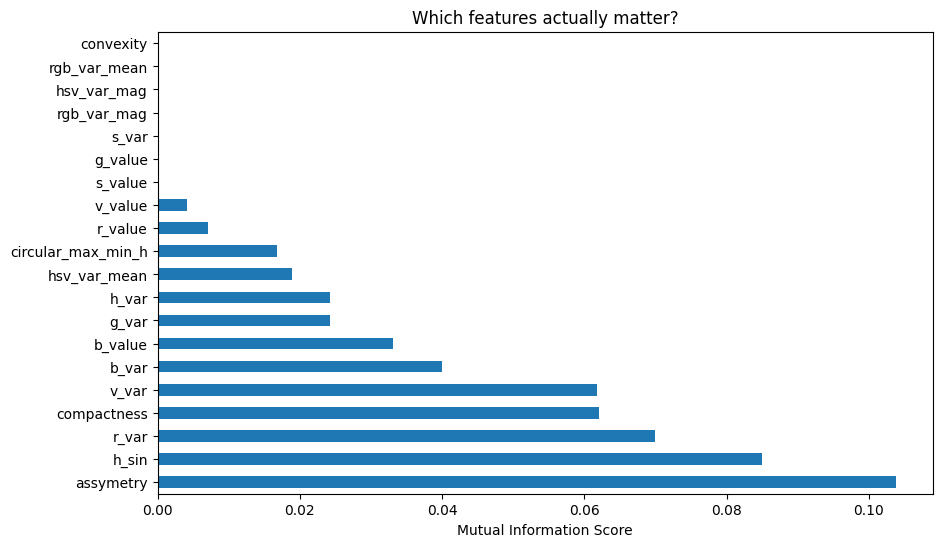

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

# 1. Simple Correlation (Linear)
# We look at how much each column relates to 'y'
# Assuming x is a DataFrame and y is a Series
df = x.copy()
df['target'] = y
correlations = df.corr()['target'].sort_values(ascending=False)

print("--- Top Linear Correlations ---")
print(correlations)

# 2. Mutual Information (Non-Linear)
# This is GREAT for KNN because it captures any kind of relationship
# 0 = no relationship, higher = stronger relationship
mi_scores = mutual_info_classif(x, y, random_state=0)
mi_series = pd.Series(mi_scores, name="MI Scores", index=x.columns)
mi_series = mi_series.sort_values(ascending=False)

print("\n--- Mutual Information Scores ---")
print(mi_series)

# 3. Quick Visualization
plt.figure(figsize=(10, 6))
mi_series.plot(kind='barh')
plt.title("Which features actually matter?")
plt.xlabel("Mutual Information Score")
plt.show()

In [33]:
important_features = ['assymetry', 'h_sin', 'r_var', 'compactness','v_var', 'b_var', 'h_var']
x_filtered = x[important_features]

# 2. Re-split with the filtered features
dev_x, test_x, dev_y, test_y = train_test_split(
    x_filtered, y, stratify=y, random_state=0, test_size=0.2
)

# 3. Scale ONLY these 3 features
scaler = StandardScaler()
dev_x_scaled = scaler.fit_transform(dev_x)
test_x_scaled = scaler.transform(test_x)

# 4. Re-run your Grid Search (using the code from before)
grid_search.fit(dev_x_scaled, dev_y)

print(f"New Best CV AUC: {grid_search.best_score_:.4f}")

New Best CV AUC: 0.7169
